In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [41]:
data=pd.read_csv("./student_dataset.csv")

In [42]:
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
57,58,Female,3.4,81.7,72.1,58.4,Pass


In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      300 non-null    int64  
 1   Gender          290 non-null    str    
 2   Study_Hours     288 non-null    float64
 3   Attendance      290 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     300 non-null    float64
 6   Result          300 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 16.5 KB


In [44]:
(data.isnull().sum()/len(data))*100

Student_ID        0.000000
Gender            3.333333
Study_Hours       4.000000
Attendance        3.333333
Previous_Score    4.000000
Final_Score       0.000000
Result            0.000000
dtype: float64

In [45]:
num=[]
cat=[]
for x in data.columns:
    if data[x].dtype=="str":
        cat.append(x)
    else:
        num.append(x)

In [46]:
num_cols=["Student_ID","Stdy_Hours","Attendence","Previous_Score","Final_Score"]
cat_cols=["Gender","Result"]

In [47]:
print(num,"hgfghfjgjgf")

['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score'] hgfghfjgjgf


In [48]:
print(cat)

['Gender', 'Result']


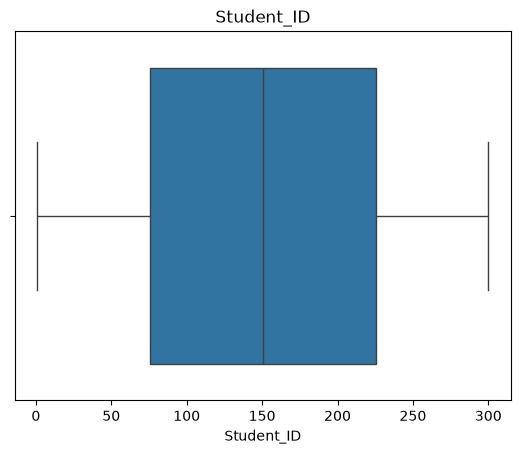

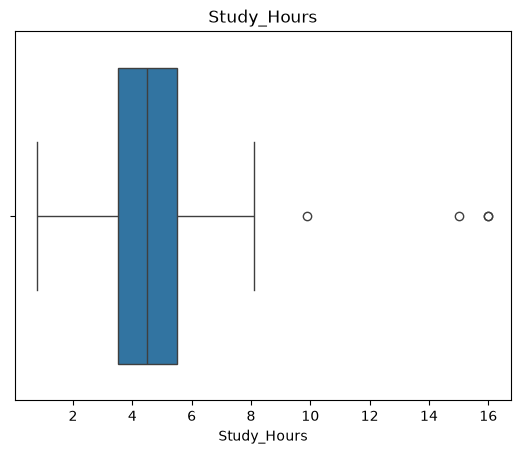

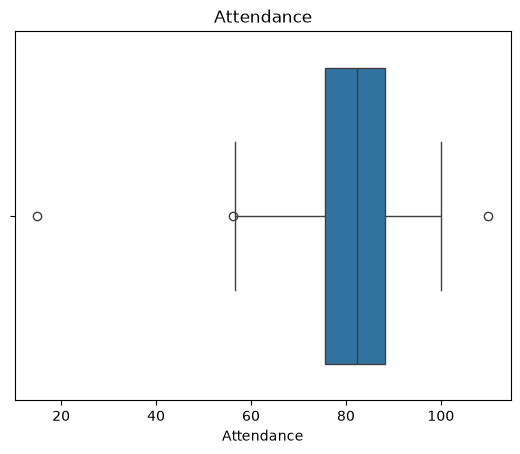

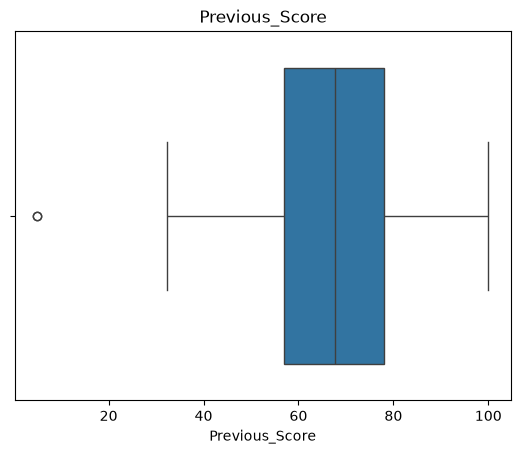

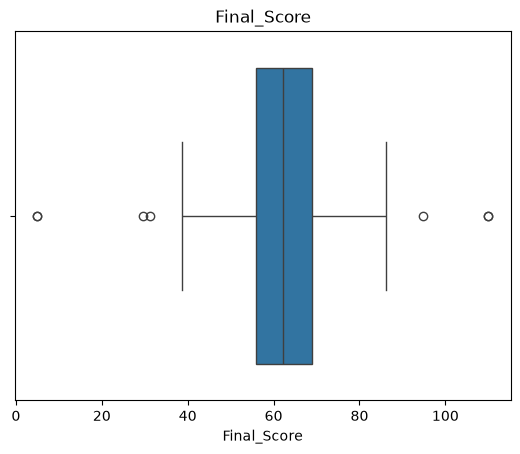

In [49]:
for col in num:
    plt.Figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [50]:
for col in num:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr=q3 - q1

    lower=q1 - 1.5 * iqr
    upper=q3 + 1.5 * iqr

    outliers= data[(data[col]<lower) | (data[col]>upper)]
    print(f"{col}: {len(outliers)} outliers")

Student_ID: 0 outliers
Study_Hours: 4 outliers
Attendance: 3 outliers
Previous_Score: 2 outliers
Final_Score: 7 outliers


In [51]:
col="Study_Hours"
q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr=q3 - q1

lower=q1 - 1.5 * iqr
upper=q3 + 1.5 * iqr

outliers= data[(data[col]<lower) | (data[col]>upper)]
print(outliers.index)
#print(f"{col}: {len(outliers)} outliers")

Index([19, 40, 79, 149], dtype='int64')


In [52]:
data=data.drop([19,40,79,149])

In [53]:
col="Attendance"
q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr=q3 - q1

lower=q1 - 1.5 * iqr
upper=q3 + 1.5 * iqr

outliers= data[(data[col]<lower) | (data[col]>upper)]
print(outliers.index)

Index([32, 98], dtype='int64')


In [54]:
data=data.drop([32,98])

In [55]:
col="Previous_Score"
q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr=q3 - q1

lower=q1 - 1.5 * iqr
upper=q3 + 1.5 * iqr

outliers= data[(data[col]<lower) | (data[col]>upper)]
print(outliers.index)

Index([59, 199], dtype='int64')


In [56]:
data=data.drop([59,199])

In [57]:
col="Final_Score"
q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr=q3 - q1

lower=q1 - 1.5 * iqr
upper=q3 + 1.5 * iqr

outliers= data[(data[col]<lower) | (data[col]>upper)]
print(outliers.index)

Index([44, 87, 169, 243], dtype='int64')


In [58]:
data=data.drop([44,87,169,243])

In [59]:
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
28,29,Female,5.4,80.0,47.8,57.1,Pass


In [60]:
for x in data.columns:
    if ((data[x].isnull().sum())>0):
        if (data[x].dtype=="str"):
            print(x,":",data[x].mode())
            data[x]=data[x].fillna(data[x].mode()[0])
            
        else:
            print(x,":",data[x].mean())
            data[x]=data[x].fillna(data[x].mean())

Gender : 0    Female
1      Male
Name: Gender, dtype: str
Study_Hours : 4.482246376811593
Attendance : 81.93597122302158
Previous_Score : 67.50613718411552


In [61]:
data.info()

<class 'pandas.DataFrame'>
Index: 288 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      288 non-null    int64  
 1   Gender          288 non-null    str    
 2   Study_Hours     288 non-null    float64
 3   Attendance      288 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     288 non-null    float64
 6   Result          288 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 18.0 KB


In [62]:
print(data.isnull().sum())

Student_ID        0
Gender            0
Study_Hours       0
Attendance        0
Previous_Score    0
Final_Score       0
Result            0
dtype: int64


<Axes: xlabel='Study_Hours', ylabel='Final_Score'>

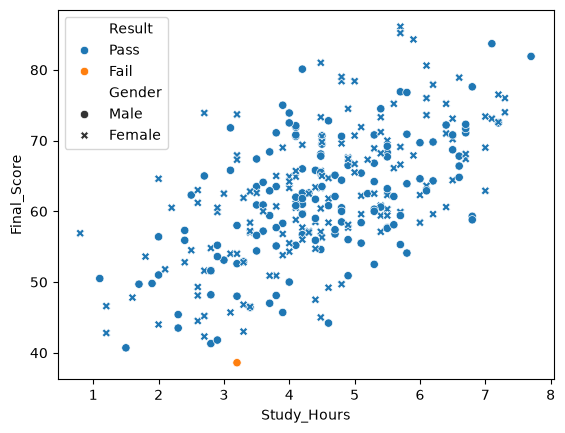

In [63]:
sns.scatterplot(data=data,y="Final_Score",x="Study_Hours",hue="Result",style="Gender")

In [64]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [65]:
for x in data.columns:
    if data[x].dtype=="str":
        data[x]=LE.fit_transform(data[x])

In [66]:
data.info()

<class 'pandas.DataFrame'>
Index: 288 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      288 non-null    int64  
 1   Gender          288 non-null    int64  
 2   Study_Hours     288 non-null    float64
 3   Attendance      288 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     288 non-null    float64
 6   Result          288 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 18.0 KB


In [67]:
data.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [68]:
x=data.drop(columns=["Result","Student_ID"])

In [69]:
y=data["Result"]

In [70]:
from sklearn.linear_model import LogisticRegression
LOGR=LogisticRegression()

In [71]:
LOGR.fit(x,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [72]:
LOGR.predict(x)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [73]:
LOGR.score(x,y)

1.0

In [74]:
import joblib 
joblib.dump(LE,"LabelE.pkl")
joblib.dump(LOGR,"LogRegression.pkl")

['LogRegression.pkl']

In [75]:
print(data['Result'].value_counts())

Result
1    287
0      1
Name: count, dtype: int64
